### HuyIGW04 - One Sample Training - Linear Regression - PyTorch - M05W02

In [56]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np

In [57]:
# .float() để đưa về float32 cho giống với nn.Linear
# reshape để đưa vào tính toán trong ma trận cho hợp lí
data = np.genfromtxt('data.csv', delimiter=',')
X = torch.from_numpy(data[:, 0]).float().reshape(-1, 1).to("cuda")
y = torch.from_numpy(data[:, 1]).float().reshape(-1, 1).to("cuda")
print(X.shape, y.shape)

torch.Size([4, 1]) torch.Size([4, 1])


In [ ]:
N = X.shape[0]
losses = []

# setting
linear = nn.Linear(1, 1).to("cuda")
loss = nn.MSELoss()
optimizer = torch.optim.SGD(linear.parameters(), lr=0.0001)

# one sample training
for epoch in range(100):
    for i in range(N):
        # for each sample
        x_i = X[i]
        y_i = y[i]

        # compute predict
        y_hat = linear(x_i)

        # compute loss
        loss_sample = loss(y_hat, y_i)
        losses.append(loss_sample.item())

        # derivative
        optimizer.zero_grad()
        loss_sample.backward()

        # update weight
        optimizer.step()

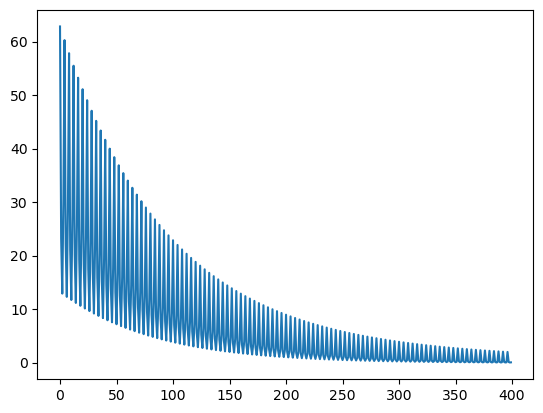

In [59]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [60]:
# inference
linear(X)

tensor([[7.7064],
        [5.5684],
        [4.4485],
        [6.4847]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [61]:
device = next(linear.parameters()).device
print(f"Model is on {device}")  

Model is on cuda:0
